In [1]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

from catboost import CatBoostClassifier

In [6]:
train_values = pd.read_csv('train_values.csv')
train_labels = pd.read_csv('train_labels.csv')
test_values = pd.read_csv('test_values.csv')

train = train_values.merge(train_labels, on='building_id')

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   building_id                             260601 non-null  int64
 1   geo_level_1_id                          260601 non-null  int64
 2   geo_level_2_id                          260601 non-null  int64
 3   geo_level_3_id                          260601 non-null  int64
 4   count_floors_pre_eq                     260601 non-null  int64
 5   age                                     260601 non-null  int64
 6   area_percentage                         260601 non-null  int64
 7   height_percentage                       260601 non-null  int64
 8   land_surface_condition                  260601 non-null  str  
 9   foundation_type                         260601 non-null  str  
 10  roof_type                               260601 non-null  str  
 11  ground_floo

In [8]:
X = train.drop(['damage_grade', 'building_id'], axis=1)
y = train['damage_grade']

print(X.shape)
print(y.shape)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

(260601, 38)
(260601,)


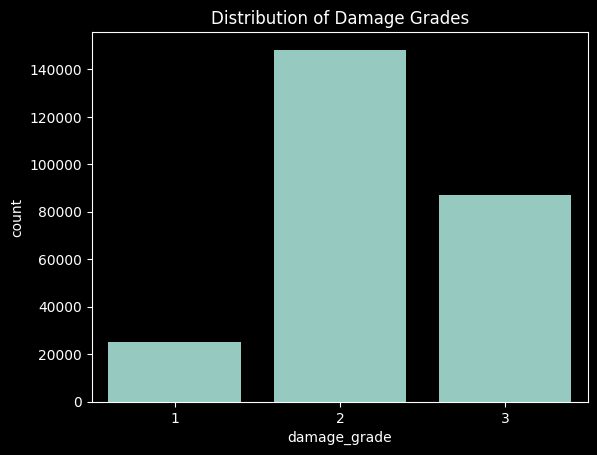

In [9]:
sns.countplot(x=y)
plt.title("Distribution of Damage Grades")
plt.show()

Random Forest — Train/Test Split

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        #max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_val)

rf_f1 = f1_score(y_val, rf_pred, average='micro')
print("RF Validation F1:", rf_f1)

RF Validation F1: 0.7236430613380403


Random Forest — Confusion Matrix

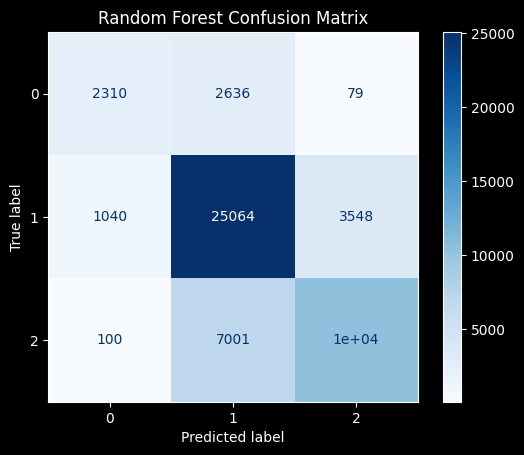

In [11]:
cm = confusion_matrix(y_val, rf_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

Random Forest — Cross Validation

In [12]:
rf_cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring='f1_micro',
    n_jobs=-1
)

print("RF CV Scores:", rf_cv_scores)
print("RF Mean CV:", rf_cv_scores.mean())

RF CV Scores: [0.72295236 0.72018419 0.72488488 0.72711051 0.7240023 ]
RF Mean CV: 0.7238268497607028


CatBoost — Train/Test Split

In [13]:
cat_features = [X.columns.get_loc(col) for col in categorical_cols]

cat_model = CatBoostClassifier(
    iterations=2000,
    depth=8,
    learning_rate=0.03,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=100,
    verbose=100
)

cat_pred = cat_model.predict(X_val)
cat_pred = cat_pred.astype(int).flatten()

cat_f1 = f1_score(y_val, cat_pred, average='micro')
print("CatBoost Validation F1:", cat_f1)

0:	learn: 0.6312020	test: 0.6333148	best: 0.6333148 (0)	total: 261ms	remaining: 8m 41s
100:	learn: 0.6671527	test: 0.6663725	best: 0.6665835 (99)	total: 28.8s	remaining: 9m 1s
200:	learn: 0.6833221	test: 0.6830452	best: 0.6831028 (199)	total: 54.8s	remaining: 8m 10s
300:	learn: 0.6916827	test: 0.6902208	best: 0.6904703 (299)	total: 1m 20s	remaining: 7m 37s
400:	learn: 0.6986186	test: 0.6960726	best: 0.6960726 (400)	total: 1m 47s	remaining: 7m 7s
500:	learn: 0.7048926	test: 0.7012337	best: 0.7013296 (499)	total: 2m 11s	remaining: 6m 33s
600:	learn: 0.7103895	test: 0.7053587	best: 0.7053779 (599)	total: 2m 34s	remaining: 5m 59s
700:	learn: 0.7146249	test: 0.7095796	best: 0.7095988 (699)	total: 2m 56s	remaining: 5m 27s
800:	learn: 0.7184190	test: 0.7125727	best: 0.7125727 (800)	total: 3m 20s	remaining: 5m
900:	learn: 0.7212874	test: 0.7150477	best: 0.7152587 (889)	total: 3m 44s	remaining: 4m 33s
1000:	learn: 0.7240838	test: 0.7166977	best: 0.7166977 (1000)	total: 4m 8s	remaining: 4m 8s
11

CatBoost — Confusion Matrix

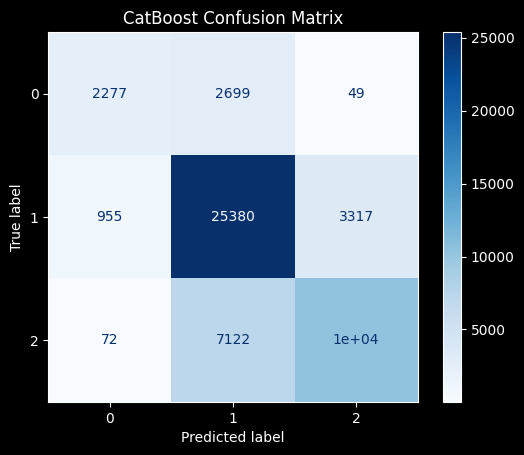

In [14]:
cm = confusion_matrix(y_val, cat_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("CatBoost Confusion Matrix")
plt.show()

CatBoost — Feature Importance

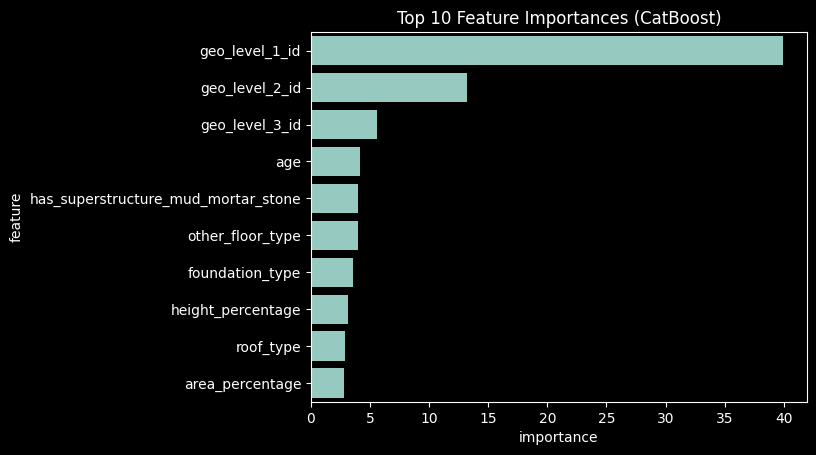

In [15]:
feature_importance = cat_model.get_feature_importance()

feat_imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)

sns.barplot(data=feat_imp_df.head(10), x='importance', y='feature')
plt.title("Top 10 Feature Importances (CatBoost)")
plt.show()

CatBoost — Cross Validation

In [16]:
cat_model_cv = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.03,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=0
)

cat_cv_scores = cross_val_score(
    cat_model_cv,
    X,
    y,
    cv=5,
    scoring='f1_micro',
    params={'cat_features': cat_features},
    n_jobs=1
)

print("CatBoost CV Scores:", cat_cv_scores)
print("CatBoost Mean CV:", cat_cv_scores.mean())

CatBoost CV Scores: [0.71475989 0.71189563 0.71694167 0.71327705 0.71613584]
CatBoost Mean CV: 0.714602015503125


In [31]:
print("=== MODEL COMPARISON ===\n")

print("Random Forest:")
print(f"Validation F1: {rf_f1:.4f}")
print(f"CV Mean F1: {rf_cv_scores.mean():.4f}\n")

print("CatBoost:")
print(f"Validation F1: {cat_f1:.4f}")
print(f"CV Mean F1: {cat_cv_scores.mean():.4f}")

=== MODEL COMPARISON ===

Random Forest:
Validation F1: 0.7236
CV Mean F1: 0.7238

CatBoost:
Validation F1: 0.7273
CV Mean F1: 0.7146


In [30]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "CatBoost"],
    "Validation F1": [rf_f1, cat_f1],
    "CV Mean F1": [rf_cv_scores.mean(), cat_cv_scores.mean()]
})

comparison_df

,Model,Validation F1,CV Mean F1
0,Random Forest,0.723643,0.723827
1,CatBoost,0.727288,0.714602


Random Forest achieved consistent performance across validation and cross-validation (both F1 scores ≈ 0.724).
CatBoost achieved a higher validation score (0.727), but its cross-validation performance (0.715) was lower, suggesting that gradient boosting is more sensitive to data splits and requires more careful tuning than Random Forest.
However, the confusion matrix shows that CatBoost performs better on the majority class (damage grade 1) and reduces extreme misclassifications, so it better captures subtle differences between damage levels.

Submission for Random Forest model

In [ ]:
rf_pipeline.fit(X, y)

X_test = test_values.drop('building_id', axis=1)

rf_preds = rf_pipeline.predict(X_test)

submission_rf = pd.DataFrame({
    'building_id': test_values['building_id'],
    'damage_grade': rf_preds.astype(int)
})

submission_rf.to_csv('submission_rf.csv', index=False)
submission_rf.head()

Submission for CatBoost model

In [ ]:
cat_model.fit(X, y, cat_features=cat_features)

cat_preds = cat_model.predict(X_test)
cat_preds = cat_preds.astype(int).flatten()

submission_cat = pd.DataFrame({
    'building_id': test_values['building_id'],
    'damage_grade': cat_preds
})

submission_cat.to_csv('submission_catboost.csv', index=False)
submission_cat.head()

-----